In [1]:
import pandas as pd 



df1= pd.read_csv(r"Data\DatasetWithLocations.csv")
df2 =pd.read_csv(r"Data\documentidentifier_id.csv")

df_join = pd.merge(df1, df2, left_on='GKGRECORDID', right_on='GKGRECORDID', how='inner')

df = df_join
df['Date'] = pd.to_datetime(df['DATE'], format='%Y%m%d%H%M%S')


df['Year-Month'] = df['Date'].dt.strftime('%Y-%m')


df[['tone','positive_score','negative_score','polarity', 'activity_density','self_group_density','word_count']] = df_join['V2Tone'].str.split(',', expand=True).astype(float)

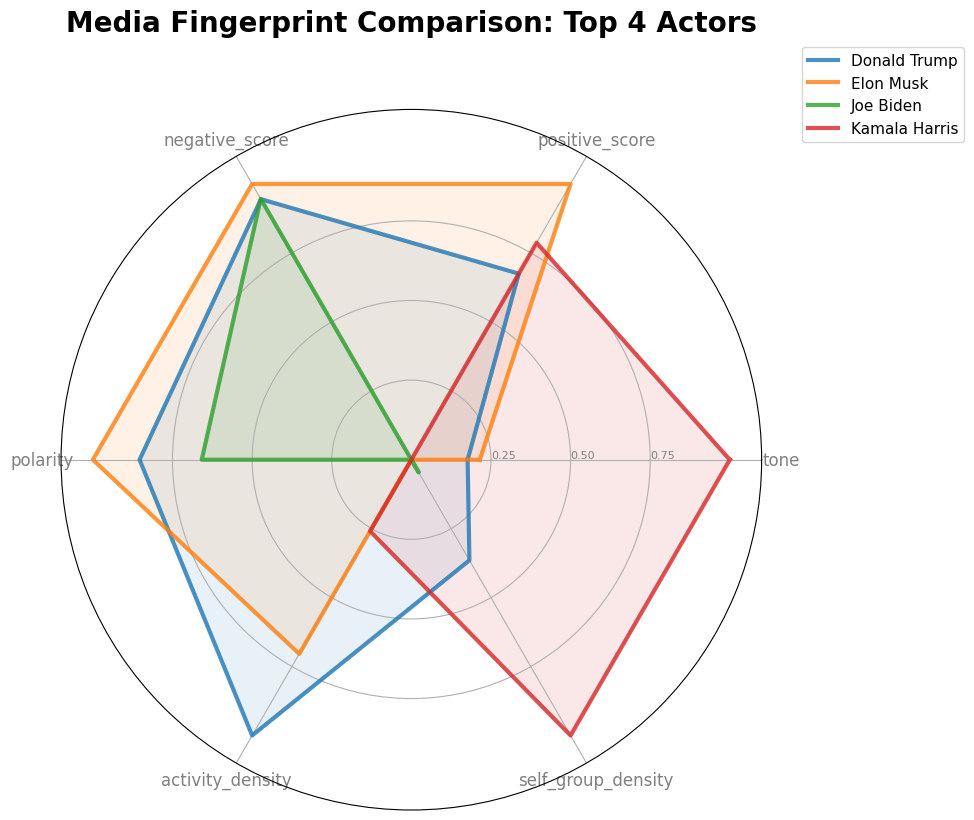

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def create_english_fingerprint_viz(df):
    # 1. Data Cleaning & Expansion
    df_exploded = df.assign(V2Persons=df['V2Persons'].str.split(';')).explode('V2Persons')
    df_exploded['PersonName'] = df_exploded['V2Persons'].str.split(',').str[0].str.strip()
    
    # Exclude non-person entities like 'Los Angeles'
    blacklist = ['Los Angeles']
    df_exploded = df_exploded[~df_exploded['PersonName'].isin(blacklist)]
    df_exploded = df_exploded[df_exploded['PersonName'] != '']
    
    # 2. Define Metrics
    metrics = ['tone', 'positive_score', 'negative_score', 'polarity', 'activity_density', 'self_group_density']
    
    # 3. Aggregate Top 4 Actors
    top_names = df_exploded['PersonName'].value_counts().head(4).index
    profiles = df_exploded[df_exploded['PersonName'].isin(top_names)].groupby('PersonName')[metrics].mean()
    
    # 4. Normalization for the Radar Chart
    scaler = MinMaxScaler()
    normalized_profiles = pd.DataFrame(
        scaler.fit_transform(profiles),
        columns=profiles.columns,
        index=profiles.index
    )
    
    # 5. Radar Chart Construction
    num_vars = len(metrics)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1] # Close the circle
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    # Define colors for the 4 actors
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, person in enumerate(normalized_profiles.index):
        values = normalized_profiles.loc[person].tolist()
        values += values[:1]
        ax.plot(angles, values, color=colors[i], linewidth=3, label=person, alpha=0.8)
        ax.fill(angles, values, color=colors[i], alpha=0.1)
    
    # Styling
    plt.xticks(angles[:-1], metrics, color='grey', size=12)
    ax.set_rlabel_position(0)
    plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", size=8)
    plt.ylim(0, 1.1)
    
    plt.title('Media Fingerprint Comparison: Top 4 Actors', size=20, y=1.1, fontweight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Run the analysis on your dataframe
create_english_fingerprint_viz(df)